# Wine Quality Prediction using Machine Learning
**Module:** CSC-44112 – Advanced Applications of AI and ML  
**Topic:** Predict wine quality based on physicochemical properties.  
**Dataset:** WineQT.csv

# ==========================
# IMPORTING LIBRARIES
# ==========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

# ==========================
# DATA LOADING
# ==========================

In [2]:
# Load the dataset
import os
data_path = '../data/WineQT.csv'
if not os.path.exists(data_path):
    print("Dataset not found. Ensure you have run data/download_dataset.py")
else:
    df = pd.read_csv(data_path)
    print("Dataset Shape:", df.shape)
    display(df.head())

Dataset Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# ==========================
# EXPLORATORY DATA ANALYSIS
# ==========================

### 1. Quality Distribution

C:\Users\AppData\Local\Temp\ipykernel_29540\820141413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='viridis')


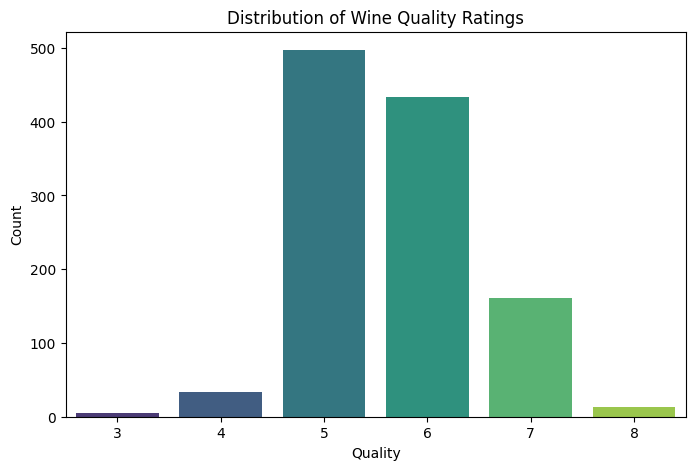

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality', palette='viridis')
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

### 2. Correlation Matrix

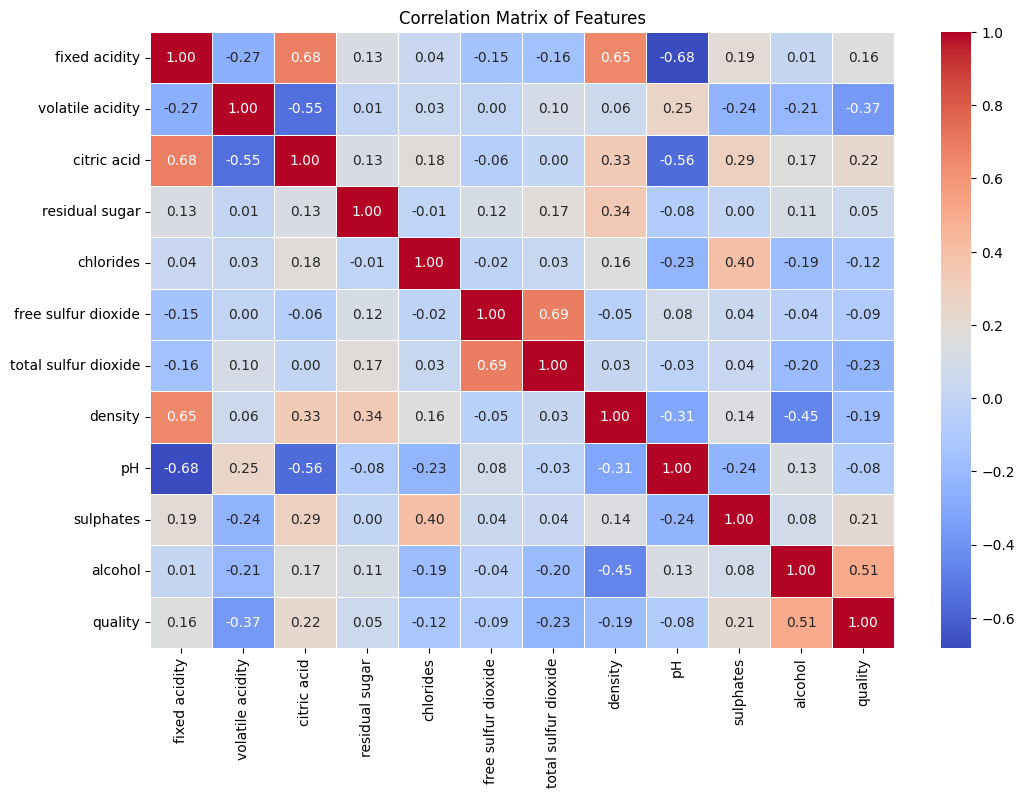

In [4]:
plt.figure(figsize=(12, 8))
corr = df.drop('Id', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

### 3. Feature Outliers (Boxplots)

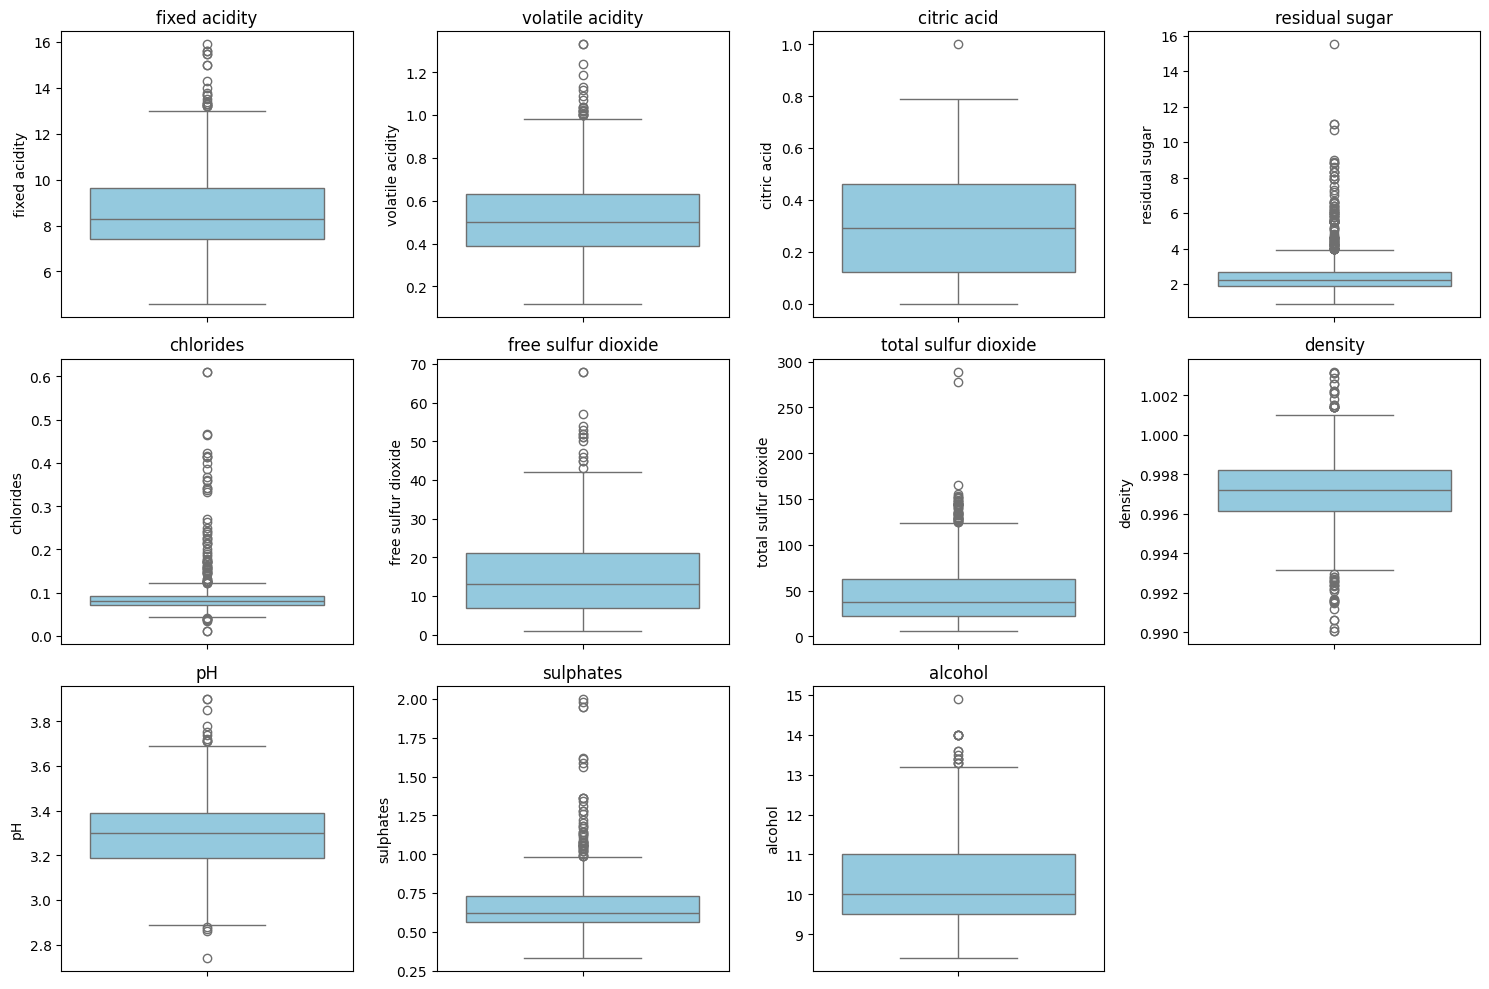

In [5]:
features = df.drop(['Id', 'quality'], axis=1).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

### 4. Histograms

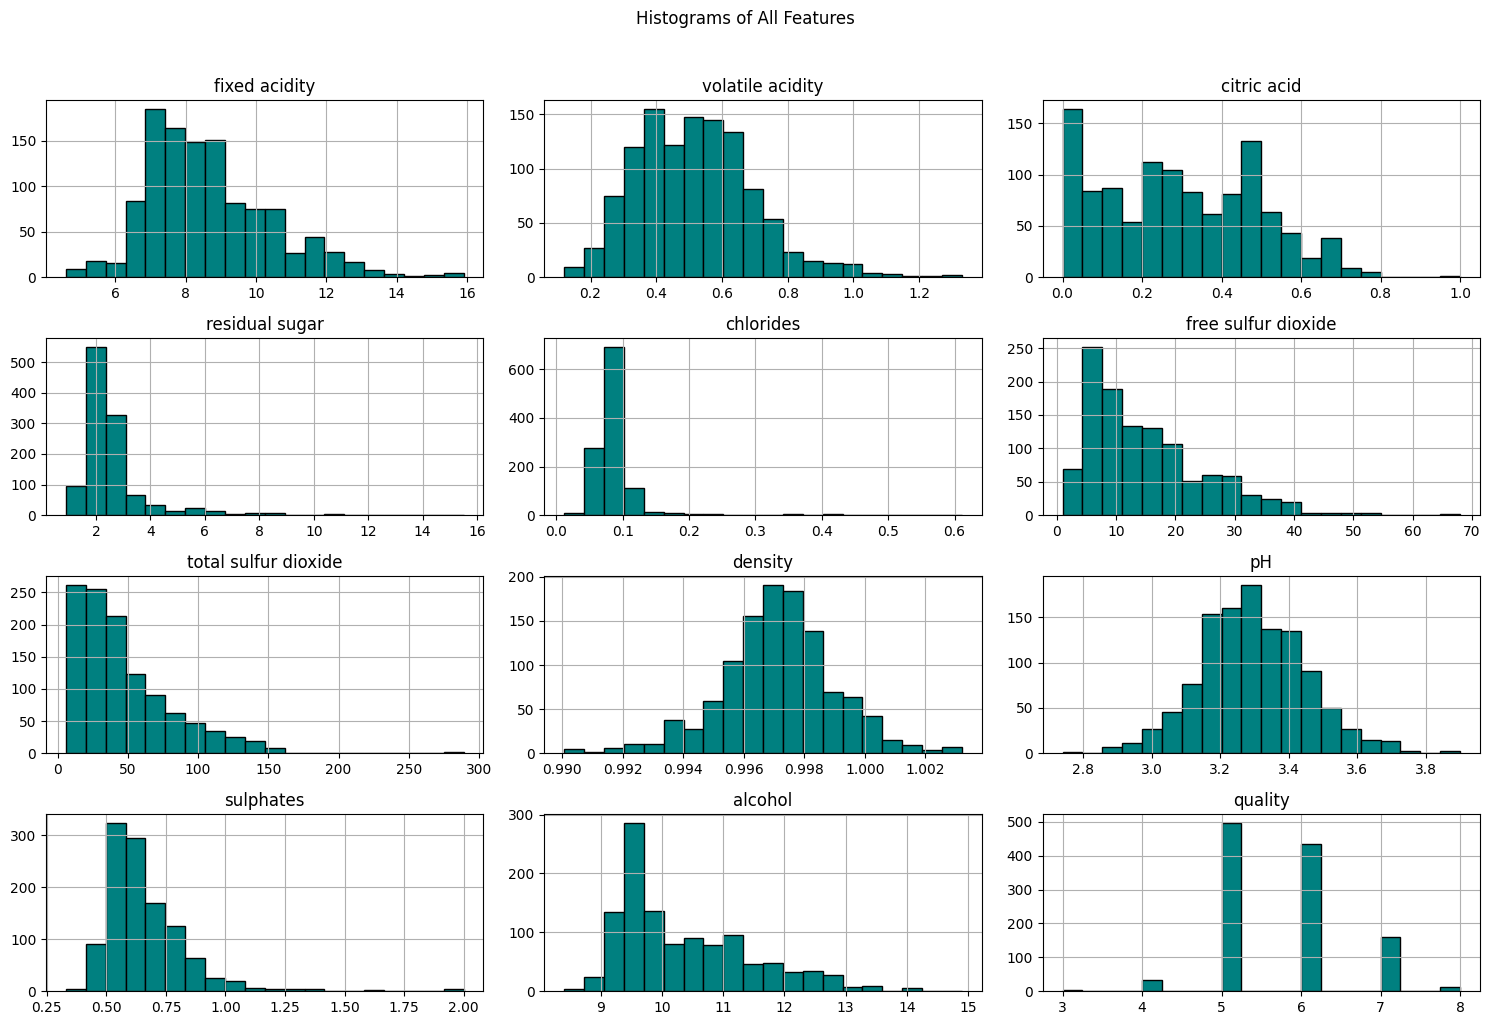

In [6]:
df.drop(['Id'], axis=1).hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout()
plt.show()

# ==========================
# DATA PREPROCESSING
# ==========================

In [7]:
# Drop the Id column
X = df.drop(['Id', 'quality'], axis=1)

# Binarize the target variable (Good Wine >= 6, Bad Wine < 6)
y = (df['quality'] >= 6).astype(int)

# Train-Test Split (80-20) with Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (914, 11)
Testing set shape: (229, 11)


# ==========================
# MODEL TRAINING
# ==========================

In [8]:
# Initialize Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to hold trained models
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
print("All models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


All models trained successfully.


# ==========================
# MODEL EVALUATION
# ==========================


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       107
           1       0.76      0.74      0.75       122

    accuracy                           0.73       229
   macro avg       0.73      0.73      0.73       229
weighted avg       0.73      0.73      0.73       229



<Figure size 1000x800 with 0 Axes>

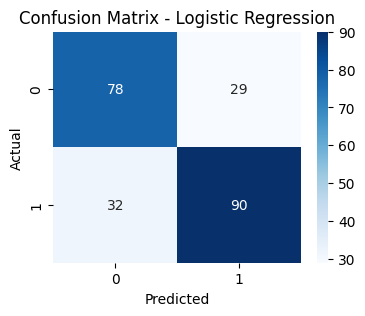


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.71      0.75       107
           1       0.77      0.83      0.80       122

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



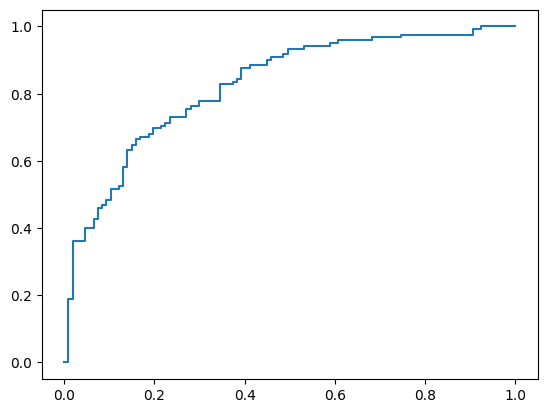

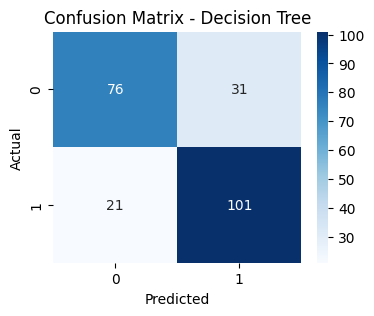


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       107
           1       0.78      0.90      0.84       122

    accuracy                           0.81       229
   macro avg       0.82      0.81      0.81       229
weighted avg       0.82      0.81      0.81       229



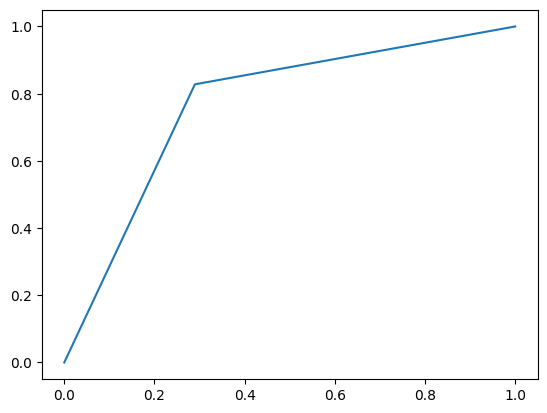

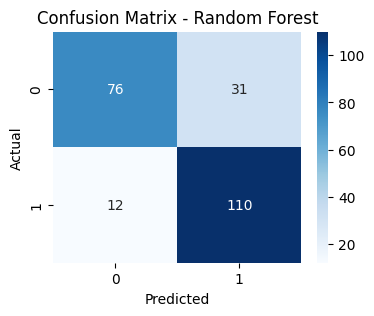

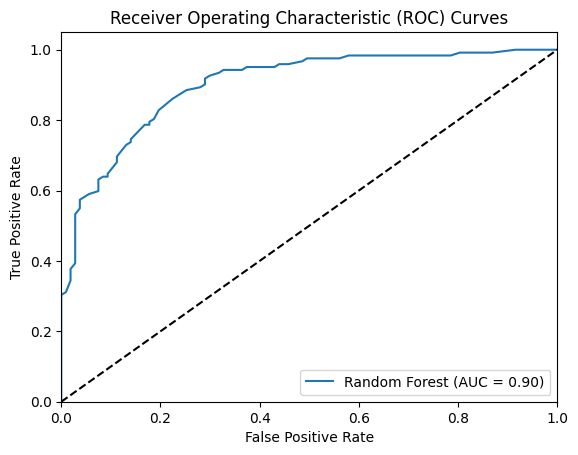

In [9]:
results = []

plt.figure(figsize=(10, 8)) # Prepare for ROC Curves

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # ROC Curve Data
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(1) # Switch back to ROC Figure
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Show ROC Curves
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

In [10]:
# Model Comparison Table
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.812227,0.780142,0.901639,0.836502
1,Decision Tree,0.772926,0.765152,0.827869,0.795276
0,Logistic Regression,0.733624,0.756303,0.737705,0.746888


# ==========================
# CONCLUSION
# ==========================
Based on the evaluation metrics, **Random Forest** provides the highest performance across Accuracy, Precision, Recall, and F1-Score, while effectively reducing overfitting and variance typical in single decision trees. The ROC curve further validates that Random Forest exhibits the best discriminatory ability among the evaluated algorithms.